In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from urllib.parse import urlparse
import requests
from bs4 import BeautifulSoup
import ollama
import time
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
def search_strategy_urls(query, api_key):
    url = "https://serpapi.com/search"

    params = {
        "q": query,
        "api_key": api_key,
        "engine": "google"
    }

    response = requests.get(url, params=params)
    data = response.json()

    urls = []

    for result in data.get("organic_results", []):
        if "link" in result:
            urls.append(result["link"])

    return urls

queries = [
    '"stock trading strategy" moving average crossover',
    '"stock trading strategy" RSI',
    '"stock trading strategy" MACD',
    '"stock trading strategy" Bollinger Bands',
    '"stock trading strategy" breakout',
    '"stock trading strategy" mean reversion',
    '"stock trading strategy" momentum',
    '"stock trading strategy" trend following',
    '"stock trading strategy" pairs trading',
    '"stock trading strategy" statistical arbitrage',
    '"stock trading strategy" support resistance',
    '"stock trading strategy" volume',
    '"stock trading strategy" VWAP',
    '"stock trading strategy" gap trading',
    '"stock trading strategy" range trading',
    '"stock trading strategy" reversal',
    '"stock trading strategy" scalping',
    '"stock trading strategy" swing trading',
    '"stock trading strategy" day trading',
    '"stock trading strategy" position trading',
    '"stock trading strategy" multi timeframe',
    '"stock trading strategy" price action',
    '"stock trading strategy" candlestick',
    '"stock trading strategy" earnings',
    '"stock trading strategy" pairs trading entry exit rules'
]

all_urls = []
API_KEY = "b627b29297e736b18078a2fd5cbcfb770d7fa7b0814701711428b0241d8037c3"

for query in queries:
    urls = search_strategy_urls(query, API_KEY)
    all_urls.extend(urls)

all_urls = list(set(all_urls))

In [3]:
def scrape_strategy(url):
    domain = urlparse(url).netloc
    source = domain.removeprefix("www.").split(".")[0]

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        if response.status_code != 200:
            print(f"Failed: {url} ({response.status_code})")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()

        text = soup.get_text(" ", strip=True)

        return {
            "source": source,
            "url": url,
            "raw_text": text
        }

    except requests.RequestException as e:
        return {
            "url": url,
            "raw_text": None,
            "error": str(e)
        }

In [4]:
strategies = []

for url in all_urls:
    strategy = scrape_strategy(url)

    if strategy is not None:
        strategies.append(strategy)

for i, strategy in enumerate(strategies, start=1):
    strategy["id"] = i

with open("data/raw_strategies.json", "w", encoding="utf-8") as f:
    json.dump(strategies, f, indent=4, ensure_ascii=False)

Failed: https://www.researchgate.net/publication/381354641_Research_on_Display_of_Stock_Trading_Reversal_Points_and_Abnormal_Points_Based_on_Hurst_Model (403)
Failed: https://www.udemy.com/course/three-profitable-swing-trading-strategies-how-to-guide/?srsltid=AfmBOoplUsprxwsln1Kxk6mZsZjRI1mZm7PhKe_BbK1RFXXA-4eyJDak (403)
Failed: https://medium.com/@redsword_23261/moving-average-crossover-strategy-e25caec17cf6 (403)
Failed: https://www.investopedia.com/articles/active-trading/051315/how-trade-stocks-hit-alltime-highs.asp (402)
Failed: https://www.quora.com/In-quantitative-fiance-how-does-pairs-trading-work-Please-also-add-how-to-find-certain-stocks-that-have-a-strong-correlation (403)
Failed: https://www.vantagemarkets.com/en-za/academy/course/stock-beginner-course/stock-beginner-course-8/ (403)
Failed: https://www.tradu.com/en/guide/stocks/trading-strategies/ (403)
Failed: https://www.quora.com/How-effective-is-the-10-20-day-MA-crossover-in-stock-trading (403)
Failed: https://medium.co

In [5]:
with open("data/raw_strategies.json", "r", encoding="utf-8") as f:
    strategies = json.load(f)

In [7]:
def extract_strategy(raw_text):
    prompt = f"""
Extract ONE primary stock trading strategy from the text below.

Return exactly:

{{
  "strategy_type": null,
  "direction": null,
  "asset_type": null,
  "timeframe": null,
}}

Rules:
- Extract only ONE primary strategy.
- strategy_type, direction, asset_type, and timeframe must each be
  either ONE string or null.
- Use null, never "Unknown".
- If multiple timeframes appear, choose the timeframe that belongs to
  the primary strategy.
- Do not invent missing information.
- Ignore unrelated webpage content.

TEXT:
{raw_text[:8000]}
"""

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {"role": "user", "content": prompt}
        ],
        format="json"
    )

    return json.loads(response["message"]["content"])

In [8]:
structured_strategies = []

for strategy in strategies:
    try:
        structured = extract_strategy(strategy["raw_text"])

        structured["id"] = strategy["id"]
        structured["source"] = strategy["source"]
        structured["url"] = strategy["url"]

        structured_strategies.append(structured)

        print(f"Finished {strategy['id']}")

        time.sleep(1)

    except Exception as e:
        print(f"Failed on strategy {strategy['id']}: {e}")

Finished 1
Failed on strategy 2: 'NoneType' object is not subscriptable
Finished 3
Finished 4
Finished 5
Finished 6
Finished 7
Finished 8
Finished 9
Finished 10
Finished 11
Finished 12
Finished 13
Finished 14
Finished 15
Finished 16
Finished 17
Finished 18
Finished 19
Finished 20
Finished 21
Finished 22
Finished 23
Finished 24
Finished 25
Finished 26
Finished 27
Failed on strategy 28: an error was encountered while running the model: CUDA error (status code: 500)
Failed on strategy 29: 'NoneType' object is not subscriptable
Finished 30
Finished 31
Finished 32
Finished 33
Finished 34
Finished 35
Finished 36
Finished 37
Finished 38
Finished 39
Finished 40
Finished 41
Finished 42
Finished 43
Finished 44
Finished 45
Finished 46
Finished 47
Finished 48
Failed on strategy 49: Expecting ':' delimiter: line 19 column 32 (char 2057)
Finished 50
Finished 51
Finished 52
Finished 53
Finished 54
Finished 55
Finished 56
Finished 57
Finished 58
Finished 59
Finished 60
Finished 61
Finished 62
Finished

In [45]:
def is_valid_strategy(s):
    fields = ["strategy_type", "direction", "asset_type", "timeframe"]
    return sum(s.get(field) is not None for field in fields) >= 3

In [27]:
structured_strategies = [
    s for s in structured_strategies
    if is_valid_strategy(s)
]

In [28]:
with open("data/structured_strategies.json", "w", encoding="utf-8") as f:
    json.dump(structured_strategies, f, indent=4, ensure_ascii=False)

In [29]:
df = pd.DataFrame(structured_strategies)

df.head()

,strategy_type,direction,asset_type,timeframe,id,source,url
0,Swing Trading,NaN,Stocks,Weekly,3,morpheustrading,https://morpheustrading.com/blog/top-5-qualiti...
1,NaN,long-term,stocks,years,15,nerdwallet,https://www.nerdwallet.com/investing/learn/sto...
2,Volume-Based,NaN,Stocks,Daily,20,linkedin,https://www.linkedin.com/pulse/how-identify-av...
3,Momentum,NaN,Stocks,Short to mid-term,22,moomoo,https://www.moomoo.com/ca/learn/detail-momentu...
4,Momentum Trading,Long,Stocks,Daily,26,music,https://music.amazon.com/podcasts/cf5790fe-a48...


In [30]:
df["asset_type"] = (
    df["asset_type"]
    .astype(str)
    .str.lower()
    .replace({
        "stocks": "stock",
        "nan": None
    })
)

df["timeframe"] = (
    df["timeframe"]
    .astype(str)
    .str.lower()
    .replace({
        "1d": "daily",
        "nan": None
    })
)

df["strategy_type"] = (
    df["strategy_type"]
    .astype(str)
    .str.lower()
    .replace({
        "breakout strategy": "breakout",
        "momentum trading": "momentum",
        "momentum portfolio": "momentum",
        "nan": None
    })
)

In [31]:
categorical = [
    "strategy_type",
    "direction",
    "asset_type",
    "timeframe"
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(df[categorical])

In [32]:
X_categorical.shape

(11, 23)

In [33]:
X_categorical[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0.])

In [34]:
encoder.get_feature_names_out()

array(['strategy_type_mean reversion', 'strategy_type_momentum',
       'strategy_type_neuroevolution of augmenting topologies (neat)',
       'strategy_type_scalping', 'strategy_type_statistical arbitrage',
       'strategy_type_swing trading', 'strategy_type_volatility trading',
       'strategy_type_volume-based', 'strategy_type_nan',
       'direction_Long', 'direction_long-term', 'direction_nan',
       'asset_type_forex', 'asset_type_stock', 'timeframe_1-5 minutes',
       'timeframe_1-day interval', 'timeframe_daily',
       'timeframe_long-term', 'timeframe_pre-earnings',
       'timeframe_short to mid-term', 'timeframe_short-term',
       'timeframe_weekly', 'timeframe_years'], dtype=object)

In [35]:
X_categorical

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0.,

In [36]:
X_categorical = encoder.fit_transform(df[categorical])

print(X_categorical.shape)
print(encoder.get_feature_names_out())

(11, 23)
['strategy_type_mean reversion' 'strategy_type_momentum'
 'strategy_type_neuroevolution of augmenting topologies (neat)'
 'strategy_type_scalping' 'strategy_type_statistical arbitrage'
 'strategy_type_swing trading' 'strategy_type_volatility trading'
 'strategy_type_volume-based' 'strategy_type_nan' 'direction_Long'
 'direction_long-term' 'direction_nan' 'asset_type_forex'
 'asset_type_stock' 'timeframe_1-5 minutes' 'timeframe_1-day interval'
 'timeframe_daily' 'timeframe_long-term' 'timeframe_pre-earnings'
 'timeframe_short to mid-term' 'timeframe_short-term' 'timeframe_weekly'
 'timeframe_years']


In [37]:
X = X_categorical

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X)

In [38]:
df["cluster"] = clusters

In [39]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
]

,strategy_type,direction,asset_type,timeframe,cluster
0,swing trading,NaN,stock,weekly,1
1,NaN,long-term,stock,years,2
2,volume-based,NaN,stock,daily,1
3,momentum,NaN,stock,short to mid-term,1
4,momentum,Long,stock,daily,0
5,statistical arbitrage,NaN,stock,long-term,1
6,scalping,Long,forex,1-5 minutes,0
7,NaN,Long,stock,short-term,0
8,volatility trading,NaN,stock,pre-earnings,1
9,mean reversion,NaN,stock,long-term,1


In [40]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [41]:
X_pca.shape

(11, 2)

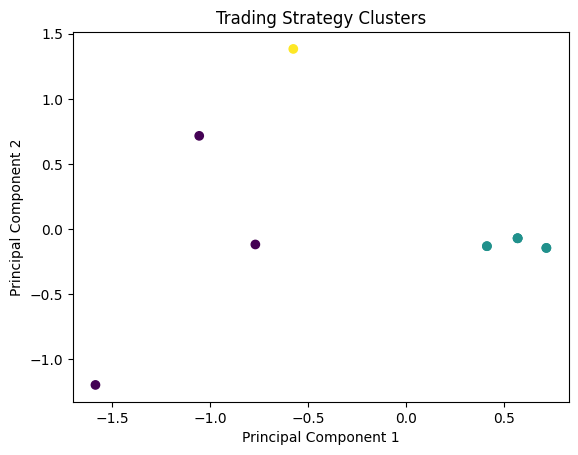

In [42]:


plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Trading Strategy Clusters")

plt.show()

In [43]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
].sort_values("cluster")

,strategy_type,direction,asset_type,timeframe,cluster
6,scalping,Long,forex,1-5 minutes,0
7,NaN,Long,stock,short-term,0
4,momentum,Long,stock,daily,0
0,swing trading,NaN,stock,weekly,1
2,volume-based,NaN,stock,daily,1
3,momentum,NaN,stock,short to mid-term,1
5,statistical arbitrage,NaN,stock,long-term,1
8,volatility trading,NaN,stock,pre-earnings,1
10,neuroevolution of augmenting topologies (neat),NaN,stock,1-day interval,1
9,mean reversion,NaN,stock,long-term,1
